In [30]:
import pandas as pd 
import numpy as np
# data pre processing
patients = pd.read_csv("patients.csv")
diagnoses = pd.read_csv("diagnoses.csv")
labs = pd.read_csv("labs.csv")
outcomes = pd.read_csv("outcomes.csv")


In [31]:
# data merging 
patients = patients.merge(diagnoses,on = "DiagnosisID")
patients = patients.merge(outcomes , on = "OutcomeID")

In [32]:
# changing data type of admisson date and discharge dage 
patients["AdmissionDate"] = pd.to_datetime(patients["AdmissionDate"])
patients["DischargeDate"] = pd.to_datetime(patients["DischargeDate"])
patients["LengthofStay"] = (patients["DischargeDate"] - patients["AdmissionDate"]).dt.days


In [33]:
patients["OutcomeEncoded"] = patients["OutcomeName"].map({"Recovered" : 0 ,"Complicated ": 1," Deceased" :1 })

In [ ]:
# high risk indicator age > 65 and outcome = complicated or disease than high risk
#patients["HighRisk"] = np.where((patients["Age"]> 65 )) | (patients["OutcomeName"].isin(["Complicated","Deceased" ]),1,0 )
                                     

In [ ]:
# high risk indicator age > 65 and outcome = complicated or disease than high risk
patients["HighRisk"] = np.where(
    (patients["Age"] > 65) |
    (patients["OutcomeName"].isin(["Complicated", "Deceased"])),
    1,
    0
)

In [49]:
# abnormal conditions
abnormal_conditions ={
    "Blood Sugar" : lambda x: x>120 or x<80 ,
    "Cholestrol" : lambda x: x>200 or x <150 ,
    "Hemoglobin ": lambda x: x<13 ,
    "Creatinine" : lambda x :x>120 or x <80,
    "Vitamin D" : lambda x: x>17 or x <13
}

def count_Abnormal_labs(patient_id) :
    patient_labs = labs[labs["PatientID"] == patient_id]
    count = 0 
    for test_name ,condition in abnormal_conditions.items():
        test_result = patient_labs[patient_labs["TestName"] ==  test_name]
        count += test_result["Result"].apply(condition).sum()
        return count
patients["AbnormalLabCount"] = patients["PatientID"].apply(count_Abnormal_labs)


In [71]:
# model training 
features = patients[["Age" , "LengthofStay","TreatmentCost" ]] # input fpr the model
# target for the model 
target = patients["OutcomeEncoded"]


In [72]:
# splitting the data  how much data to test or how much to train 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(features,target,test_size = 0.3,random_state = 42)

In [73]:
"""ml 
supervised  input + output - linear regression , logistic regression 
unsuperivsed - input only
reinforcment - rewards """

'ml \nsupervised  input + output - linear regression , logistic regression \nunsuperivsed - input only\nreinforcment - rewards '

In [74]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter= 500)
model.fit(x_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [75]:
# evaluating model caluclatiing accuracy ,classification report and confusion model

from sklearn.metrics import classification_report,confusion_matrix
y_pred = model.predict(x_test)
print("classification report")
print(classification_report(y_test,y_pred))

classification report
              precision    recall  f1-score   support

           0       0.76      0.93      0.84        41
           1       0.70      0.37      0.48        19

    accuracy                           0.75        60
   macro avg       0.73      0.65      0.66        60
weighted avg       0.74      0.75      0.72        60



In [76]:
# ROC curve

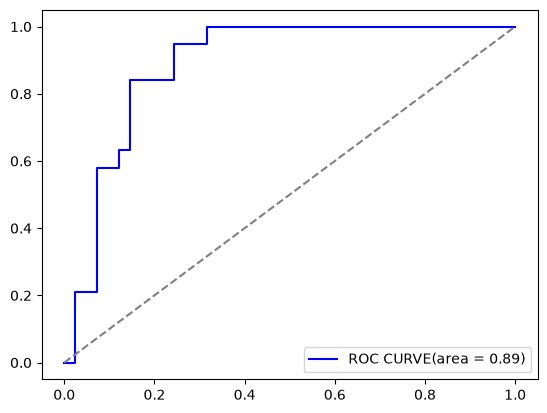

In [77]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve ,auc

y_prob = model.predict_proba(x_test)[:,1]
fpr , tpr, thresholds = roc_curve(y_test,y_prob)
roc_auc = auc(fpr,tpr)
plt.figure()
plt.plot(fpr,tpr,color = 'blue' , label = f"ROC CURVE(area = {roc_auc :.2f})")
plt.plot([0,1],[0,1],color = "grey",linestyle = "--")
plt.xlabel = ("false positive rate")
plt.ylabel= ( " true positive rate")
plt.title = ("reciever operating characteristics")
plt.legend(loc = "lower right")
plt.show()


In [78]:
import joblib
joblib.dump(model,"Risk_Model.ipynb")

['Risk_Model.ipynb']

In [79]:
import streamlit as st
import pandas as pd
import joblib

model = joblib.load("Risk_Model.ipynb")

st.title("HealthCare Risk Stratisfication App")

age = st.number_input("Age" , min_value = 0 )
length_of_stay = st.number_input("Length of stay (days)", min_value = 0)
treatment_cost = st.number_input("Treatment Cost ",min_value = 0)

if st.button("Predict"):
    input_data = pd.DataFrame([[age,length_of_stay,treatment_cost]],columns = ["Age"," LengthofStay","TreatmentCost"])
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    st.write(f"Risk Prediction :{'High Risk' if prediction == 1 else 'Low risk'}" )
    st.write(f"Risk Probability : {round(probability,2)}")




2026-08-31 20:16:49.114 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-31 20:16:49.114 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-31 20:16:49.115 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-31 20:16:49.115 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-31 20:16:49.115 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-31 20:16:49.116 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-31 20:16:49.116 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-31 20:16:49.116 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar